# CDA_23301

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')
# 全局设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

FILE_PATH = './Data/Online_Retail_23301_Cleaned.xlsx'
OUTPUT_EXCEL = './RFM_23301_User_Segmentation.xlsx'
OUTPUT_PNG = './RFM_23301_Segments_BarChart.png'

正在读取数据...
有效订单记录: 762 条
RFM 参考日期 (Snapshot Date): 2011-12-10
参与分层的客户数: 405

=== 用户分层统计 ===
用户类型
Regular Customers                164
Important at-risk customers       84
Important Value Customers         62
Important development clients     44
Important retain customers        26
General Value Customers           25
Name: count, dtype: int64

RFM 分层结果已保存至: ./RFM_23301_User_Segmentation.xlsx


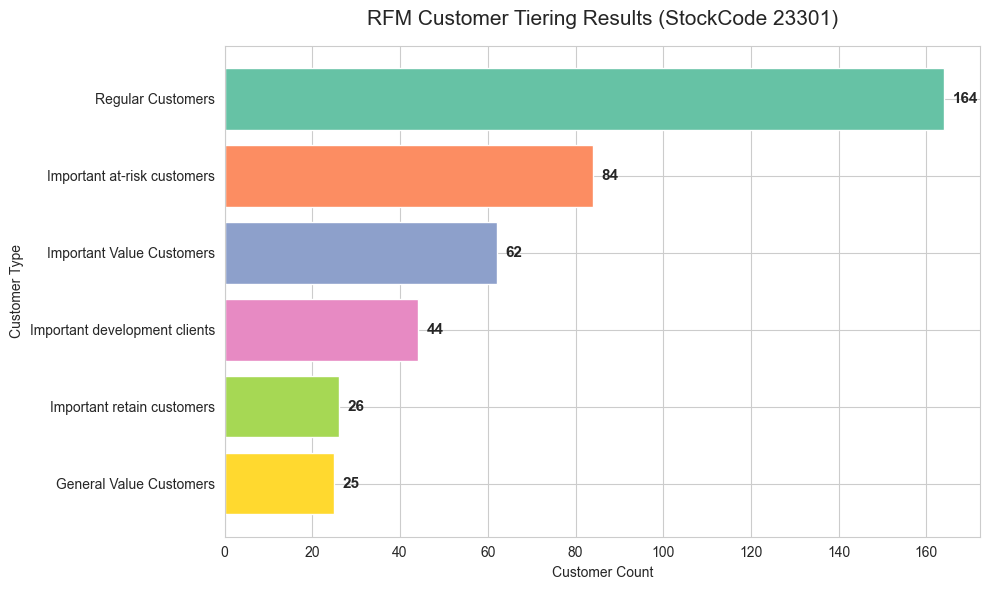

用户分层柱状图已保存至: ./RFM_23301_Segments_BarChart.png


In [2]:
def main():
    # 1. 读取数据
    print("正在读取数据...")
    df = pd.read_excel(FILE_PATH)
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    
    # 只取正常订单（排除退货单）
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C', na=False)].copy()
    print(f"有效订单记录: {len(df):,} 条")

    if df.empty:
        print("错误: 没有有效订单数据，程序终止。")
        return

    # 2. 计算 RFM 指标
    # 使用数据集中最大日期 +1 作为参考日期（更贴近业务实际）
    snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)
    print(f"RFM 参考日期 (Snapshot Date): {snapshot_date.date()}")

    rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
        'InvoiceNo': 'nunique',                                    # Frequency
        'TotalAmount': 'sum'                                       # Monetary
    }).reset_index()
    rfm.columns = ['CustomerID', 'R', 'F', 'M']
    print(f"参与分层的客户数: {len(rfm)}")

    # 3. 五分位打分 (1-5 分)
    # R 越小分越高（最近购买越好），F/M 越大分越高
    rfm['R_Score'] = pd.qcut(rfm['R'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)
    rfm['F_Score'] = pd.qcut(rfm['F'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
    rfm['M_Score'] = pd.qcut(rfm['M'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
    rfm['RFM_Score'] = (
        rfm['R_Score'].astype(str) + 
        rfm['F_Score'].astype(str) + 
        rfm['M_Score'].astype(str)
    )

    # 4. 用户分层映射
    def rfm_segment(row):
        r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
        if r >= 4 and f >= 4 and m >= 4:
            return 'Important Value Customers'
        elif r >= 4 and f <= 2:
            return 'Important development clients'
        elif r <= 2 and f >= 4 and m >= 4:
            return 'Important retain customers'
        elif r <= 2 and f <= 2:
            return 'Important at-risk customers'
        elif r >= 4 and f >= 2 and m <= 2:
            return 'General Value Customers'
        else:
            return 'Regular Customers'
    
    rfm['用户类型'] = rfm.apply(rfm_segment, axis=1)

    # 5. 统计各分层人数
    seg_count = rfm['用户类型'].value_counts()
    print("\n=== 用户分层统计 ===")
    print(seg_count)

    # 6. 保存 Excel
    rfm.to_excel(OUTPUT_EXCEL, index=False)
    print(f"\nRFM 分层结果已保存至: {OUTPUT_EXCEL}")

    # 7. 绘制柱状图
    plt.figure(figsize=(10, 6))
    colors = sns.color_palette("Set2", len(seg_count))
    
    bars = plt.barh(seg_count.index[::-1], seg_count.values[::-1], color=colors[::-1])
    
    # 在柱子右侧标注数值
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 2, bar.get_y() + bar.get_height()/2, 
                 f'{int(width)}', va='center', fontsize=11, fontweight='bold')
    
    plt.title('RFM Customer Tiering Results (StockCode 23301)', fontsize=15, pad=15)
    plt.xlabel('Customer Count')
    plt.ylabel('Customer Type')
    plt.tight_layout()
    plt.savefig(OUTPUT_PNG, dpi=300)
    plt.show()
    print(f"用户分层柱状图已保存至: {OUTPUT_PNG}")


if __name__ == '__main__':
    main()

# 购买 23301的客户RFM分群表格
| RFM类型 | 客户数 | 占比 | 全局占比（对照） | 差异（百分点） |
| :--- | :--- | :--- | :--- | :--- |
| Regular Customers（常规客户） | 164 | 40.49% | 38.81% | +1.68 |
| Important at-risk customers（重要风险客户） | 84 | 20.74% | 24.83% | -4.09 |
| Important Value Customers（重要价值客户） | 62 | 15.31% | 21.87% | -6.56 |
| Important development clients（重要发展客户） | 44 | 10.86% | 7.20% | +3.66 |
| Important retain customers（重要留存客户） | 26 | 6.42% | 3.93% | +2.49 |
| General Value Customers（一般价值客户） | 25 | 6.17% | 3.36% | +2.81 |
| 合计 | 405 | 100% | — | — |

## 客户分析
1. 核心客户群体特征
</br>常规客户是绝对主力，但属于自然分布：常规客户占比 40.49%，略高于全局平均水平（38.81%，差异+1.68个百分点）。这说明常规客户确实是购买人数最多的类型，但这种优势属于群体基数的自然体现，而非该商品具有特殊的刻意吸引力。
2. 推翻原有假设的负面发现
</br>反驳"批发商主导"假设：重要价值客户（高F高M的批发商群体）占比仅为 15.31%，显著低于全局平均水平（21.87%，差异-6.56个百分点）。这直接推翻了初稿中"增长主要来自批发商季节性备货"的推测，证明该商品的高增长并非由核心批发商群体驱动。
</br>排除"沉睡唤醒"逻辑：重要风险客户（高R值、长期未购买的沉睡客户）占比为 20.74%，低于全局平均水平（24.83%，差异-4.09个百分点）。这表明该商品并不具备特别强的唤醒沉睡客户能力。
3. 真正的高配潜力人群
</br>重要发展客户（低F高M，近期购买但频次低的新兴客户）：占比 10.86%（高于全局平均+3.66个百分点）；
</br>一般价值客户（低F低M的低价值客户）：占比 6.17%（高于全局平均+2.81个百分点）；
</br>重要留存客户（高F低M，高频但低消费的忠诚客户）：占比 6.42%（高于全局平均+2.49个百分点）。